In [10]:
%load_ext autoreload
%autoreload 2
import numpy as np
import analysis_code.get_data
import matplotlib.pyplot as plt
import analysis_code.population_activity as pop
import analysis_code.helper_functions as hf
import analysis_code.analysis as analysis
import analysis_code.plots as plots
import analysis_code.statistics_test as st

from IPython.display import display, HTML
def print_large(text):
    display(HTML(f"<span style='font-size: 20px;'>{text}</span>"))

from pathlib import Path
#OUT = Path("figures"); OUT.mkdir(exist_ok=True)
import matplotlib as mpl
mpl.rcParams.update({
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
    "pdf.fonttype": 42,   
    "ps.fonttype": 42,    
})

DATA_ROOT = 'DATAPATH'  
datapaths = [
    f'{DATA_ROOT}/170.h5',
    f'{DATA_ROOT}/51004.h5',
    f'{DATA_ROOT}/51007.h5',
    f'{DATA_ROOT}/63.h5',
    f'{DATA_ROOT}/64.h5',
    f'{DATA_ROOT}/65.h5',
]

animal_ids = st.animal_labels(datapaths)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:

def analyze_data_common(datapath, reference, maps, analysis_type, method='subspace', compute_day11_12=False, 
                        transients=False, dim_red=False, max_dim=4, standardize='stand'):
    def get_analysis_function(analysis_type):
        if analysis_type == 'population_geometry':
            return analysis.populationgeometry, analysis.populationgeometry_context
        elif analysis_type == 'topology':
            return analysis.topology_analysis, analysis.topology_analysis_context


    analysis_func, context_func = get_analysis_function(analysis_type)

    def apply_analysis(func, *args):
        if analysis_type == 'population_geometry':
            return func(*args, method=method)
        else:
            return func(*args, max_dim=max_dim)

    hists = analysis.sort_maps_from_reference_AK(datapath, 'Context1', reference=reference, maps=maps, reference_type='no_reference',
                                                  hist='hist', transients=transients, dim_red=dim_red, 
                                                  standardize=standardize, remove_day_inactive=False)
    #hists=hists[::-1] 
    g = apply_analysis(analysis_func, hists)

    global_seeds = [1,2,3,4,5]
    simu_g_list = []
    for seed in global_seeds:
        simu_drift = analysis.simulate_drift(datapath, session='0', Context='Context1', days=len(maps)+1, 
                                             drift_type='circular', dim_red=dim_red, standardize=standardize, odd_even=True, 
                                             global_seed=seed, active_days=[reference]+maps, remove_day_inactive=True, 
                                             max_remap_prob=0.3, amplitude_drift_prob=0.3, amplitude_change_scale=0.5)
        simu_g = apply_analysis(analysis_func, simu_drift['maps'])
        simu_g_list.append(simu_g)
    simu_g_array = np.array(simu_g_list)
    simu_g = np.mean(simu_g_array, axis=0)

    hist_odd, hist_even = analysis.sort_maps_from_reference_within_session_AK(datapath, 'Context1', maps=maps, 
                                                                                  transients=transients, dim_red=dim_red,
                                                                                    standardize=standardize, remove_day_inactive=False)
    g_odd_even1 = apply_analysis(context_func, hist_odd, hist_even)

    if analysis_type == 'population_geometry':      

        shuff1, shuff2 = analysis.shuffle_two_sessions_hist(datapath, '0', '19', 'Context1', dim_red=dim_red, remove_inactive=[reference]+maps, 
                                                            standardize=standardize, remove_day_inactive=False)
        g_shuff1 = apply_analysis(context_func, [shuff1], [shuff2])

        
        g = (g - np.mean(g_odd_even1)) / (np.mean(g_shuff1) - np.mean(g_odd_even1))
        simu_g = (simu_g - np.mean(g_odd_even1)) / (np.mean(g_shuff1) - np.mean(g_odd_even1))
    else:
        g = g-np.mean(g_odd_even1)
        simu_g = simu_g-np.mean(g_odd_even1)
  
    return g, simu_g


def collect_data(datapaths, reference, maps, analysis_type, method='subspace', compute_day11_12=False, transients=False, dim_red=False, max_dim=3, standardize='stand'):
    all_data = []
    for datapath in datapaths:
        data = analyze_data_common(datapath, reference, maps, analysis_type, method=method, compute_day11_12=compute_day11_12, transients=transients, dim_red=dim_red, max_dim=max_dim, standardize=standardize)
        all_data.append(data)
    return all_data

if __name__ == "__main__":
    transients = False
    dim_red = False
    max_dim = 4

    reference = '0'
    maps = [str(i) for i in np.arange(1, 13)] +  ['14', '15', '17', '19']
    forward_data_pop_geometry_subspace = collect_data(datapaths, reference, maps, 'population_geometry', method='subspace', compute_day11_12=False, transients=transients, dim_red=dim_red, standardize='stand')
    forward_data_pop_geometry_angles = collect_data(datapaths, reference, maps, 'population_geometry', method='angles', compute_day11_12=False, transients=transients, dim_red=dim_red, standardize='stand')
    forward_data_topology = collect_data(datapaths, reference, maps, 'topology', compute_day11_12=False, transients=transients, dim_red=dim_red, max_dim=max_dim, standardize='stand')



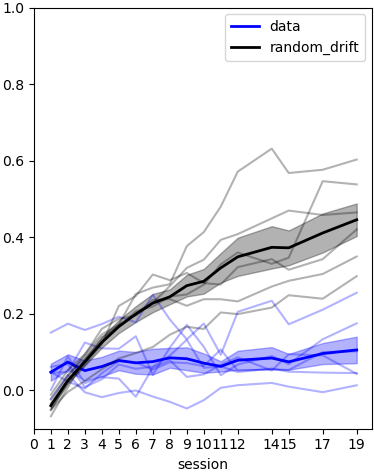

day,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,
170,-0.0218,0.0410,-0.0048,-0.0177,-0.0067,-0.0001,-0.0159,-0.0298,-0.0471,-0.0254,0.0069,0.0136,0.0196,0.0099,-0.0046,0.0135
51004,0.0010,0.0892,0.0188,0.0346,0.0309,-0.0165,0.0598,0.0792,0.0354,0.0419,0.0672,0.0862,0.0520,0.0945,0.0916,0.0433
51007,0.0461,0.0481,0.1250,0.1097,0.1088,0.1415,0.0409,0.1116,0.1713,0.1138,0.0398,0.0677,0.0897,0.0688,0.1336,0.1752
63,0.1510,0.1742,0.1579,0.1734,0.1926,0.1778,0.2498,0.1855,0.1334,0.1746,0.0930,0.2053,0.2342,0.1727,0.2108,0.2551
64,0.0616,0.0690,0.0088,0.0291,0.0677,0.0564,0.0623,0.0908,0.1323,0.0591,0.0627,0.0482,0.0571,0.0489,0.0465,0.0453
65,0.0479,0.0234,0.0049,0.0449,0.0764,0.0730,0.0546,0.0734,0.0714,0.0636,0.1069,0.0518,0.0548,0.0534,0.1000,0.1021


day,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,
170,-0.0511,0.0199,0.0673,0.1201,0.2206,0.2466,0.3027,0.2879,0.3068,0.2803,0.2765,0.3220,0.3428,0.3151,0.3429,0.4204
51004,-0.0674,0.0077,0.0812,0.1307,0.1722,0.2518,0.2686,0.2772,0.3768,0.4134,0.4800,0.5714,0.6314,0.5678,0.5763,0.6029
51007,-0.0235,0.0395,0.0871,0.1392,0.1656,0.2066,0.2192,0.2451,0.2507,0.2762,0.3293,0.3602,0.3307,0.3468,0.5464,0.5380
63,-0.0346,0.0371,0.0935,0.1609,0.1871,0.1954,0.2286,0.2724,0.3200,0.3414,0.3932,0.4082,0.4493,0.4697,0.4581,0.4649
64,-0.0112,0.0532,0.0944,0.1462,0.1717,0.1985,0.2361,0.2385,0.2210,0.2383,0.2381,0.2326,0.2713,0.2862,0.3041,0.3498
65,-0.0510,-0.0038,0.0247,0.0553,0.0835,0.0976,0.1134,0.1455,0.1662,0.1605,0.2036,0.1993,0.2163,0.2487,0.2394,0.2984


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,time,1.053608,15,75,0.070241,28.492554,6.421891e-25,0.000131,0.507114,0.123045
1,condition,1.318484,1,5,1.318484,24.372000,4.334045e-03,0.004334,0.562846,1.000000
2,time * condition,0.768201,15,75,0.051213,22.927203,4.676262e-22,0.000032,0.428624,0.169622


,Timepoint,Condition 1,Condition 2,Test Used,Statistic,p-value,Adjusted p-value (bonferroni),Significance,Effect Size,Effect Size Type,Mean Cond 1,Mean Cond 2,Mean Diff,SD Diff,N,Normal Dist.,Normality p-value
0,d1,data,random_drift,t-test,4.0405,0.0099,0.1587,,1.6495,Cohen's d,0.0476,-0.0398,0.0874,0.0530,6,True,0.1606
1,d2,data,random_drift,t-test,2.3503,0.0655,1.0000,,0.9595,Cohen's d,0.0742,0.0256,0.0486,0.0506,6,True,0.0666
2,d3,data,random_drift,t-test,-0.9052,0.4069,1.0000,,-0.3695,Cohen's d,0.0518,0.0747,-0.0229,0.0620,6,True,0.3326
3,d4,data,random_drift,t-test,-2.4917,0.0550,0.8808,,-1.0172,Cohen's d,0.0624,0.1254,-0.0631,0.0620,6,True,0.4584
4,d5,data,random_drift,t-test,-2.4620,0.0571,0.9134,,-1.0051,Cohen's d,0.0783,0.1668,-0.0885,0.0880,6,True,0.7110
5,d6,data,random_drift,t-test,-2.8303,0.0367,0.5866,,-1.1555,Cohen's d,0.0720,0.1994,-0.1274,0.1103,6,True,0.2355
6,d7,data,random_drift,t-test,-3.1452,0.0255,0.4083,,-1.2840,Cohen's d,0.0752,0.2281,-0.1529,0.1190,6,True,0.8314
7,d8,data,random_drift,t-test,-4.3505,0.0074,0.1177,,-1.7761,Cohen's d,0.0851,0.2444,-0.1593,0.0897,6,True,0.3773
8,d9,data,random_drift,t-test,-3.6638,0.0145,0.2326,,-1.4957,Cohen's d,0.0828,0.2736,-0.1908,0.1276,6,True,0.0619
9,d10,data,random_drift,t-test,-5.0837,0.0038,0.0612,,-2.0754,Cohen's d,0.0713,0.2850,-0.2138,0.1030,6,True,0.3457


day,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,
170,-0.0218,0.0410,-0.0048,-0.0177,-0.0067,-0.0001,-0.0159,-0.0298,-0.0471,-0.0254,0.0069,0.0136,0.0196,0.0099,-0.0046,0.0135
51004,0.0010,0.0892,0.0188,0.0346,0.0309,-0.0165,0.0598,0.0792,0.0354,0.0419,0.0672,0.0862,0.0520,0.0945,0.0916,0.0433
51007,0.0461,0.0481,0.1250,0.1097,0.1088,0.1415,0.0409,0.1116,0.1713,0.1138,0.0398,0.0677,0.0897,0.0688,0.1336,0.1752
63,0.1510,0.1742,0.1579,0.1734,0.1926,0.1778,0.2498,0.1855,0.1334,0.1746,0.0930,0.2053,0.2342,0.1727,0.2108,0.2551
64,0.0616,0.0690,0.0088,0.0291,0.0677,0.0564,0.0623,0.0908,0.1323,0.0591,0.0627,0.0482,0.0571,0.0489,0.0465,0.0453
65,0.0479,0.0234,0.0049,0.0449,0.0764,0.0730,0.0546,0.0734,0.0714,0.0636,0.1069,0.0518,0.0548,0.0534,0.1000,0.1021


,Source,SS,DF,MS,F,p-unc,ng2,eps
0,time,0.019806,15,0.001320,1.217173,0.278402,0.047494,0.226543
1,Error,0.081360,75,0.001085,NaN,NaN,NaN,NaN


day,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,
170,-0.0511,0.0199,0.0673,0.1201,0.2206,0.2466,0.3027,0.2879,0.3068,0.2803,0.2765,0.3220,0.3428,0.3151,0.3429,0.4204
51004,-0.0674,0.0077,0.0812,0.1307,0.1722,0.2518,0.2686,0.2772,0.3768,0.4134,0.4800,0.5714,0.6314,0.5678,0.5763,0.6029
51007,-0.0235,0.0395,0.0871,0.1392,0.1656,0.2066,0.2192,0.2451,0.2507,0.2762,0.3293,0.3602,0.3307,0.3468,0.5464,0.5380
63,-0.0346,0.0371,0.0935,0.1609,0.1871,0.1954,0.2286,0.2724,0.3200,0.3414,0.3932,0.4082,0.4493,0.4697,0.4581,0.4649
64,-0.0112,0.0532,0.0944,0.1462,0.1717,0.1985,0.2361,0.2385,0.2210,0.2383,0.2381,0.2326,0.2713,0.2862,0.3041,0.3498
65,-0.0510,-0.0038,0.0247,0.0553,0.0835,0.0976,0.1134,0.1455,0.1662,0.1605,0.2036,0.1993,0.2163,0.2487,0.2394,0.2984


,Source,SS,DF,MS,F,p-unc,ng2,eps
0,time,1.802004,15,0.120134,33.239635,5.104150e-27,0.741919,0.104799
1,Error,0.271062,75,0.003614,NaN,NaN,NaN,NaN


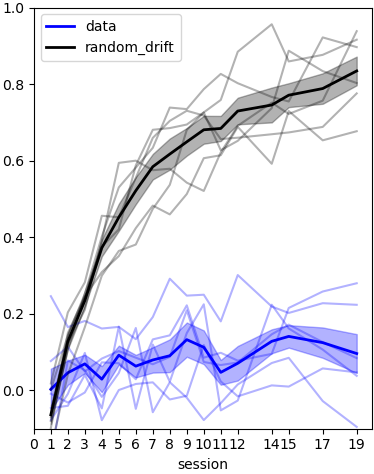

day,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,
170,-0.1733,0.0782,0.0524,-0.0168,0.0456,0.1631,-0.0569,0.0214,-0.0190,-0.0774,-0.0332,0.0156,0.0716,0.0851,-0.0278,-0.0952
51004,-0.0773,-0.0091,0.0980,-0.0778,0.0010,0.0168,0.0211,-0.0236,-0.0139,0.1185,0.0235,-0.0155,0.0132,0.0100,0.0575,0.0472
51007,0.2461,0.1655,0.1815,0.1616,0.1660,0.1338,0.1915,0.2917,0.2476,0.2499,0.1803,0.3013,0.2191,0.2023,0.2278,0.2236
63,-0.0460,-0.0401,0.0405,-0.0469,0.1666,-0.0481,0.1198,0.0228,0.1498,0.2249,-0.0521,-0.0265,0.2238,0.1619,0.1066,0.0381
64,0.0767,0.1141,0.0493,0.0832,0.1027,0.0855,0.0684,0.0875,0.2092,0.0743,0.0663,0.0730,0.1465,0.1719,0.1261,0.0844
65,-0.0087,-0.0316,-0.0054,0.0733,0.0709,0.0292,0.1333,0.1439,0.2223,0.0856,0.0983,0.0777,0.0955,0.2153,0.2583,0.2799


day,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,
170,-0.0981,0.1225,0.2105,0.3912,0.5943,0.6000,0.5751,0.5789,0.5426,0.5209,0.6218,0.6911,0.7515,0.7220,0.7568,0.9382
51004,-0.0799,0.1072,0.2527,0.3754,0.4206,0.5877,0.6807,0.6851,0.6944,0.7261,0.7586,0.8845,0.9563,0.8591,0.8764,0.9159
51007,0.0017,0.1435,0.2521,0.4017,0.5302,0.5820,0.6336,0.7387,0.7346,0.7868,0.8266,0.8023,0.7664,0.7546,0.9219,0.8965
63,-0.1541,0.0414,0.1653,0.2997,0.3643,0.3810,0.4741,0.5368,0.6803,0.7259,0.6272,0.6518,0.7372,0.8872,0.8338,0.8027
64,0.0182,0.2037,0.2822,0.4561,0.4523,0.5553,0.6595,0.7039,0.7304,0.7178,0.6564,0.6600,0.6690,0.6737,0.6882,0.7757
65,-0.0699,0.1501,0.2455,0.3091,0.3509,0.4238,0.4827,0.4597,0.5129,0.6065,0.6141,0.6882,0.5919,0.7295,0.6531,0.6769


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,time,3.775123,15,75,0.251675,45.729473,1.601499e-31,3.970152e-08,0.719304,0.211432
1,condition,10.272437,1,5,10.272437,168.875811,4.810818e-05,4.810818e-05,0.874576,1.000000
2,time * condition,2.385384,15,75,0.159026,37.295815,1.274234e-28,1.865386e-07,0.618205,0.209569


,Timepoint,Condition 1,Condition 2,Test Used,Statistic,p-value,Adjusted p-value (bonferroni),Significance,Effect Size,Effect Size Type,Mean Cond 1,Mean Cond 2,Mean Diff,SD Diff,N,Normal Dist.,Normality p-value
0,d1,data,random_drift,t-test,1.5197,0.1891,1.0000,,0.6204,Cohen's d,0.0029,-0.0637,0.0666,0.1073,6,True,0.8274
1,d2,data,random_drift,t-test,-2.9331,0.0325,0.5203,,-1.1974,Cohen's d,0.0462,0.1281,-0.0819,0.0684,6,True,0.9756
2,d3,data,random_drift,t-test,-6.0158,0.0018,0.0292,*,-2.4559,Cohen's d,0.0694,0.2347,-0.1653,0.0673,6,True,0.7209
3,d4,data,random_drift,t-test,-9.4653,0.0002,0.0036,**,-3.8642,Cohen's d,0.0294,0.3722,-0.3428,0.0887,6,True,0.4351
4,d5,data,random_drift,t-test,-7.3444,0.0007,0.0117,*,-2.9983,Cohen's d,0.0921,0.4521,-0.3599,0.1200,6,True,0.9676
5,d6,data,random_drift,t-test,-18.5695,8.3350e-06,0.0001,***,-7.5810,Cohen's d,0.0634,0.5216,-0.4582,0.0604,6,True,0.2086
6,d7,data,random_drift,t-test,-8.8167,0.0003,0.0050,**,-3.5994,Cohen's d,0.0795,0.5843,-0.5047,0.1402,6,True,0.1842
7,d8,data,random_drift,t-test,-9.4526,0.0002,0.0036,**,-3.8590,Cohen's d,0.0906,0.6172,-0.5266,0.1365,6,True,0.9946
8,d9,data,random_drift,t-test,-9.3822,0.0002,0.0037,**,-3.8303,Cohen's d,0.1326,0.6492,-0.5165,0.1349,6,True,0.5558
9,d10,data,random_drift,t-test,-24.7000,2.0287e-06,3.2460e-05,***,-10.0837,Cohen's d,0.1126,0.6807,-0.5680,0.0563,6,True,0.5684


day,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,
170,-0.1733,0.0782,0.0524,-0.0168,0.0456,0.1631,-0.0569,0.0214,-0.0190,-0.0774,-0.0332,0.0156,0.0716,0.0851,-0.0278,-0.0952
51004,-0.0773,-0.0091,0.0980,-0.0778,0.0010,0.0168,0.0211,-0.0236,-0.0139,0.1185,0.0235,-0.0155,0.0132,0.0100,0.0575,0.0472
51007,0.2461,0.1655,0.1815,0.1616,0.1660,0.1338,0.1915,0.2917,0.2476,0.2499,0.1803,0.3013,0.2191,0.2023,0.2278,0.2236
63,-0.0460,-0.0401,0.0405,-0.0469,0.1666,-0.0481,0.1198,0.0228,0.1498,0.2249,-0.0521,-0.0265,0.2238,0.1619,0.1066,0.0381
64,0.0767,0.1141,0.0493,0.0832,0.1027,0.0855,0.0684,0.0875,0.2092,0.0743,0.0663,0.0730,0.1465,0.1719,0.1261,0.0844
65,-0.0087,-0.0316,-0.0054,0.0733,0.0709,0.0292,0.1333,0.1439,0.2223,0.0856,0.0983,0.0777,0.0955,0.2153,0.2583,0.2799


,Source,SS,DF,MS,F,p-unc,ng2,eps
0,time,0.140889,15,0.009393,1.984833,0.027558,0.145253,0.224222
1,Error,0.354914,75,0.004732,NaN,NaN,NaN,NaN


day,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,
170,-0.0981,0.1225,0.2105,0.3912,0.5943,0.6000,0.5751,0.5789,0.5426,0.5209,0.6218,0.6911,0.7515,0.7220,0.7568,0.9382
51004,-0.0799,0.1072,0.2527,0.3754,0.4206,0.5877,0.6807,0.6851,0.6944,0.7261,0.7586,0.8845,0.9563,0.8591,0.8764,0.9159
51007,0.0017,0.1435,0.2521,0.4017,0.5302,0.5820,0.6336,0.7387,0.7346,0.7868,0.8266,0.8023,0.7664,0.7546,0.9219,0.8965
63,-0.1541,0.0414,0.1653,0.2997,0.3643,0.3810,0.4741,0.5368,0.6803,0.7259,0.6272,0.6518,0.7372,0.8872,0.8338,0.8027
64,0.0182,0.2037,0.2822,0.4561,0.4523,0.5553,0.6595,0.7039,0.7304,0.7178,0.6564,0.6600,0.6690,0.6737,0.6882,0.7757
65,-0.0699,0.1501,0.2455,0.3091,0.3509,0.4238,0.4827,0.4597,0.5129,0.6065,0.6141,0.6882,0.5919,0.7295,0.6531,0.6769


,Source,SS,DF,MS,F,p-unc,ng2,eps
0,time,6.019618,15,0.401308,79.699261,9.419049e-40,0.903341,0.240053
1,Error,0.377646,75,0.005035,NaN,NaN,NaN,NaN


C:\Users\oles\AppData\Local\Temp\ipykernel_30316\4118706051.py:71: UserWarning: The figure layout has changed to tight
  fig.tight_layout()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


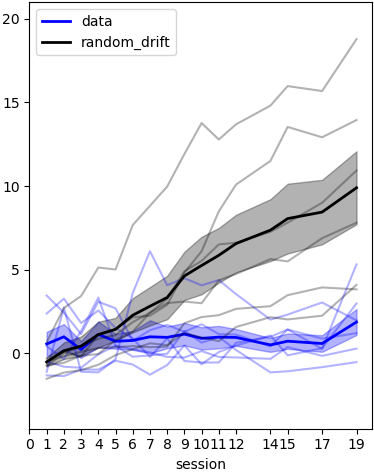

day,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,
170,-1.3120,-1.3551,-0.9631,-0.9681,-0.4363,-0.6639,-1.2724,-0.6969,0.4775,-0.6506,0.0846,0.4649,1.0710,-0.1147,0.3120,2.9846
51004,-1.0910,2.7420,-1.0979,-1.1330,-0.3452,3.6095,6.1097,4.0743,4.4937,4.0696,4.3830,3.5444,2.0195,2.3218,3.0433,1.9749
51007,0.4320,-0.3346,1.3455,3.3336,0.4569,-0.1964,-0.1169,-0.0189,1.3522,0.6413,0.9803,0.2054,-1.1341,-1.0670,-0.8204,-0.5203
63,2.3832,3.2720,1.8190,2.5633,1.5192,0.9050,-0.2083,0.8979,-0.4519,-0.5441,-0.5425,0.6348,0.9931,1.4310,0.2751,5.3202
64,3.4585,2.4345,1.1562,3.0906,2.6946,0.7551,1.3852,1.7050,1.2914,1.7426,1.1550,1.1228,0.4252,1.4318,0.8820,1.2134
65,-0.4920,-0.7942,-0.8571,-0.0525,0.4628,0.2490,0.0597,-0.2043,-0.2489,0.1419,-0.2146,-0.2406,-0.3248,0.3797,-0.1459,0.2888


day,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,
170,-1.5155,-1.1425,-1.0032,-0.6748,-0.1008,0.2486,0.6083,0.4943,1.2262,0.9481,0.7352,1.5792,2.1668,2.0301,2.2521,4.0984
51004,-0.2968,0.0847,-0.1841,1.1311,1.4574,2.1512,2.2579,2.9084,4.8224,6.1056,8.4881,10.0900,11.5026,13.5347,12.9158,13.9452
51007,-0.7043,-0.5604,-0.1378,-0.0373,0.7877,1.3059,2.4359,3.0079,3.1004,3.0004,4.3679,4.7462,5.6354,5.4995,6.8852,7.8103
63,-0.4912,-0.1654,0.0960,0.3208,0.3711,0.4416,0.3737,0.4058,1.8052,2.1735,2.2846,2.6615,2.8228,3.4821,3.9434,3.8261
64,0.6758,2.7144,3.4304,5.1336,5.0129,7.6685,8.8192,9.9726,11.9135,13.7656,12.7829,13.6893,14.8082,15.9759,15.6783,18.7808
65,-0.7519,0.0211,0.4240,0.8759,1.1009,1.8712,2.4294,3.2575,4.9097,5.5270,6.5138,6.6136,7.2662,7.8147,9.0000,10.9299


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,time,526.862515,15,75,35.124168,14.816171,1.006381e-16,0.005176,0.270909,0.089132
1,condition,528.502034,1,5,528.502034,7.734909,3.884826e-02,0.038848,0.271523,1.000000
2,time * condition,451.949134,15,75,30.129942,9.526925,5.055868e-12,0.003597,0.241699,0.144965


,Timepoint,Condition 1,Condition 2,Test Used,Statistic,p-value,Adjusted p-value (bonferroni),Significance,Effect Size,Effect Size Type,Mean Cond 1,Mean Cond 2,Mean Diff,SD Diff,N,Normal Dist.,Normality p-value
0,d1,data,random_drift,t-test,1.7726,0.1365,1.0000,,0.7237,Cohen's d,0.5631,-0.5140,1.0771,1.4884,6,True,0.3840
1,d2,data,random_drift,t-test,1.1612,0.2980,1.0000,,0.4741,Cohen's d,0.9941,0.1587,0.8354,1.7623,6,True,0.1150
2,d3,data,random_drift,t-test,-0.3148,0.7656,1.0000,,-0.1285,Cohen's d,0.2338,0.4375,-0.2038,1.5855,6,True,0.6282
3,d4,data,random_drift,t-test,0.0150,0.9886,1.0000,,0.0061,Cohen's d,1.1390,1.1249,0.0141,2.3082,6,True,0.3440
4,d5,data,random_drift,t-test,-1.4236,0.2139,1.0000,,-0.5812,Cohen's d,0.7253,1.4382,-0.7129,1.2266,6,True,0.7141
5,d6,data,random_drift,t-test,-1.2677,0.2607,1.0000,,-0.5175,Cohen's d,0.7764,2.2812,-1.5048,2.9076,6,True,0.1804
6,d7,data,random_drift,t-test,-1.2318,0.2728,1.0000,,-0.5029,Cohen's d,0.9928,2.8207,-1.8279,3.6348,6,True,0.6072
7,d8,data,random_drift,t-test,-1.7057,0.1488,1.0000,,-0.6963,Cohen's d,0.9595,3.3411,-2.3816,3.4202,6,True,0.5088
8,d9,data,random_drift,t-test,-2.1888,0.0802,1.0000,,-0.8936,Cohen's d,1.1523,4.6296,-3.4773,3.8913,6,True,0.0966
9,d10,data,random_drift,wilcoxon,0.0000,0.0312,0.5000,,0.8987,r,0.9001,5.2534,-4.3532,3.9875,6,False,0.0162


day,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,
170,-1.3120,-1.3551,-0.9631,-0.9681,-0.4363,-0.6639,-1.2724,-0.6969,0.4775,-0.6506,0.0846,0.4649,1.0710,-0.1147,0.3120,2.9846
51004,-1.0910,2.7420,-1.0979,-1.1330,-0.3452,3.6095,6.1097,4.0743,4.4937,4.0696,4.3830,3.5444,2.0195,2.3218,3.0433,1.9749
51007,0.4320,-0.3346,1.3455,3.3336,0.4569,-0.1964,-0.1169,-0.0189,1.3522,0.6413,0.9803,0.2054,-1.1341,-1.0670,-0.8204,-0.5203
63,2.3832,3.2720,1.8190,2.5633,1.5192,0.9050,-0.2083,0.8979,-0.4519,-0.5441,-0.5425,0.6348,0.9931,1.4310,0.2751,5.3202
64,3.4585,2.4345,1.1562,3.0906,2.6946,0.7551,1.3852,1.7050,1.2914,1.7426,1.1550,1.1228,0.4252,1.4318,0.8820,1.2134
65,-0.4920,-0.7942,-0.8571,-0.0525,0.4628,0.2490,0.0597,-0.2043,-0.2489,0.1419,-0.2146,-0.2406,-0.3248,0.3797,-0.1459,0.2888


,Source,SS,DF,MS,F,p-unc,ng2,eps
0,time,11.873088,15,0.791539,0.390966,0.977584,0.04693,0.1404
1,Error,151.843150,75,2.024575,NaN,NaN,NaN,NaN


day,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,
170,-1.5155,-1.1425,-1.0032,-0.6748,-0.1008,0.2486,0.6083,0.4943,1.2262,0.9481,0.7352,1.5792,2.1668,2.0301,2.2521,4.0984
51004,-0.2968,0.0847,-0.1841,1.1311,1.4574,2.1512,2.2579,2.9084,4.8224,6.1056,8.4881,10.0900,11.5026,13.5347,12.9158,13.9452
51007,-0.7043,-0.5604,-0.1378,-0.0373,0.7877,1.3059,2.4359,3.0079,3.1004,3.0004,4.3679,4.7462,5.6354,5.4995,6.8852,7.8103
63,-0.4912,-0.1654,0.0960,0.3208,0.3711,0.4416,0.3737,0.4058,1.8052,2.1735,2.2846,2.6615,2.8228,3.4821,3.9434,3.8261
64,0.6758,2.7144,3.4304,5.1336,5.0129,7.6685,8.8192,9.9726,11.9135,13.7656,12.7829,13.6893,14.8082,15.9759,15.6783,18.7808
65,-0.7519,0.0211,0.4240,0.8759,1.1009,1.8712,2.4294,3.2575,4.9097,5.5270,6.5138,6.6136,7.2662,7.8147,9.0000,10.9299


,Source,SS,DF,MS,F,p-unc,ng2,eps
0,time,966.938561,15,64.462571,18.372217,2.825856e-19,0.45105,0.087542
1,Error,263.152383,75,3.508698,NaN,NaN,NaN,NaN


In [12]:

day_cols = st.day_labels(maps)

# Subspace geometry analysis
print_large('\n' + '='*50)
print_large('RM ANOVA: SUBSPACE angles')
print_large('='*50)
fig, ax = plt.subplots(figsize=(4, 5))
g = [data[0] for data in forward_data_pop_geometry_subspace]
simu_g = [data[1] for data in forward_data_pop_geometry_subspace]
plots.plot_average_geometry([g, simu_g], maps, colors=['b', 'k'], 
                          labels=['data', 'random_drift'], 
                          plot_individual=True, ylim=[-0.1, 1], ax=ax)
plt.show()  

print_large('\nTWO-WAY REPEATED ANOVA')
anova=st.repeated_measures_anova_general(
    [np.vstack(g), np.vstack(simu_g)],
    row_labels=animal_ids, col_labels=day_cols,
    condition_labels=['data', 'random_drift'],
    title='Subspace angles vs d0: data vs random drift')
display(anova[0])
display(anova[1])
print_large('\nData: ONE-WAY RM ANOVA')
display(st.repeated_measures_anova_single_condition(
    np.vstack(g), row_labels=animal_ids, col_labels=day_cols,
    condition_label='data', title='Subspace angles vs d0: data'))
print_large('\nRandom Drift: oNE-WAY RM ANOVA')
display(st.repeated_measures_anova_single_condition(
    np.vstack(simu_g), row_labels=animal_ids, col_labels=day_cols,
    condition_label='random_drift', title='Subspace angles vs d0: random drift'))

# Angles analysis
print_large('\n' + '='*50)
print_large('RM ANOVA: Edge angles')
print_large('='*50)
fig, ax = plt.subplots(figsize=(4, 5))
g = [data[0] for data in forward_data_pop_geometry_angles]
simu_g = [data[1] for data in forward_data_pop_geometry_angles]
plots.plot_average_geometry([g, simu_g], maps, colors=['b', 'k'], 
                          labels=['data', 'random_drift'], 
                          plot_individual=True, ylim=[-0.1, 1], ax=ax)
plt.show()  

print_large('\nTWO-WAY REPEATED ANOVA')
anova=st.repeated_measures_anova_general(
    [np.vstack(g), np.vstack(simu_g)],
    row_labels=animal_ids, col_labels=day_cols,
    condition_labels=['data', 'random_drift'],
    title='Edge angles vs d0: data vs random drift')
display(anova[0])
display(anova[1])
print_large('\nData:')
display(st.repeated_measures_anova_single_condition(
    np.vstack(g), row_labels=animal_ids, col_labels=day_cols,
    condition_label='data', title='Edge angles vs d0: data'))
print_large('\nRandom Drift:')
display(st.repeated_measures_anova_single_condition(
    np.vstack(simu_g), row_labels=animal_ids, col_labels=day_cols,
    condition_label='random_drift', title='Edge angles vs d0: random drift'))

# Topology analysis
print_large('\n' + '='*50)
print_large('RM ANOVA: Persistent homology')
print_large('='*50)
fig, ax = plt.subplots(figsize=(4, 5))
g = [data[0] for data in forward_data_topology]
simu_g = [data[1] for data in forward_data_topology]
plots.plot_average_geometry([g, simu_g], maps, colors=['b', 'k'], 
                          labels=['data', 'random_drift'], 
                          plot_individual=True, ylim=[-4.5, 21], ax=ax)
fig.tight_layout()
plt.show()  

print_large('\nTWO-WAY REPEATED ANOVA')
anova=st.repeated_measures_anova_general(
    [np.vstack(g), np.vstack(simu_g)],
    row_labels=animal_ids, col_labels=day_cols,
    condition_labels=['data', 'random_drift'],
    title='Persistent homology vs d0: data vs random drift')
display(anova[0])
display(anova[1])
print_large('\nData:')
display(st.repeated_measures_anova_single_condition(
    np.vstack(g), row_labels=animal_ids, col_labels=day_cols,
    condition_label='data', title='Persistent homology vs d0: data'))
print_large('\nRandom Drift:')
display(st.repeated_measures_anova_single_condition(
    np.vstack(simu_g), row_labels=animal_ids, col_labels=day_cols,
    condition_label='random_drift', title='Persistent homology vs d0: random drift'))

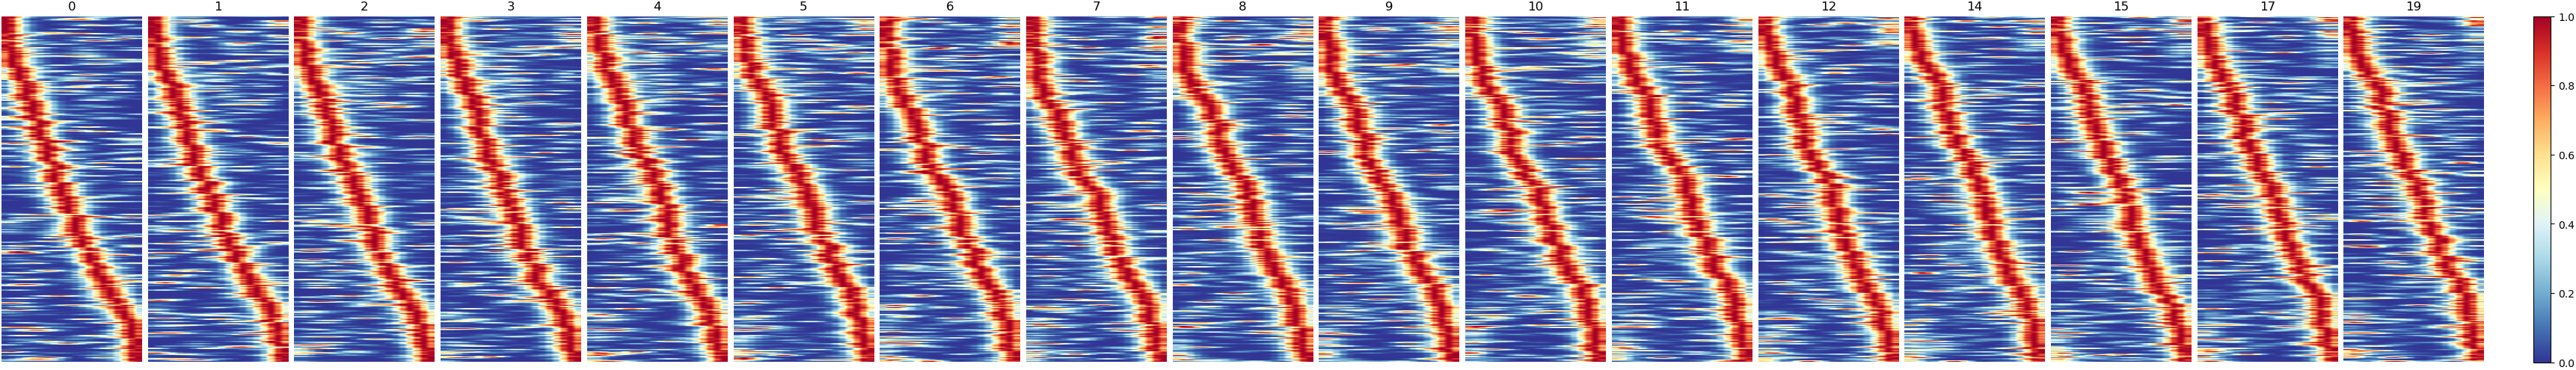

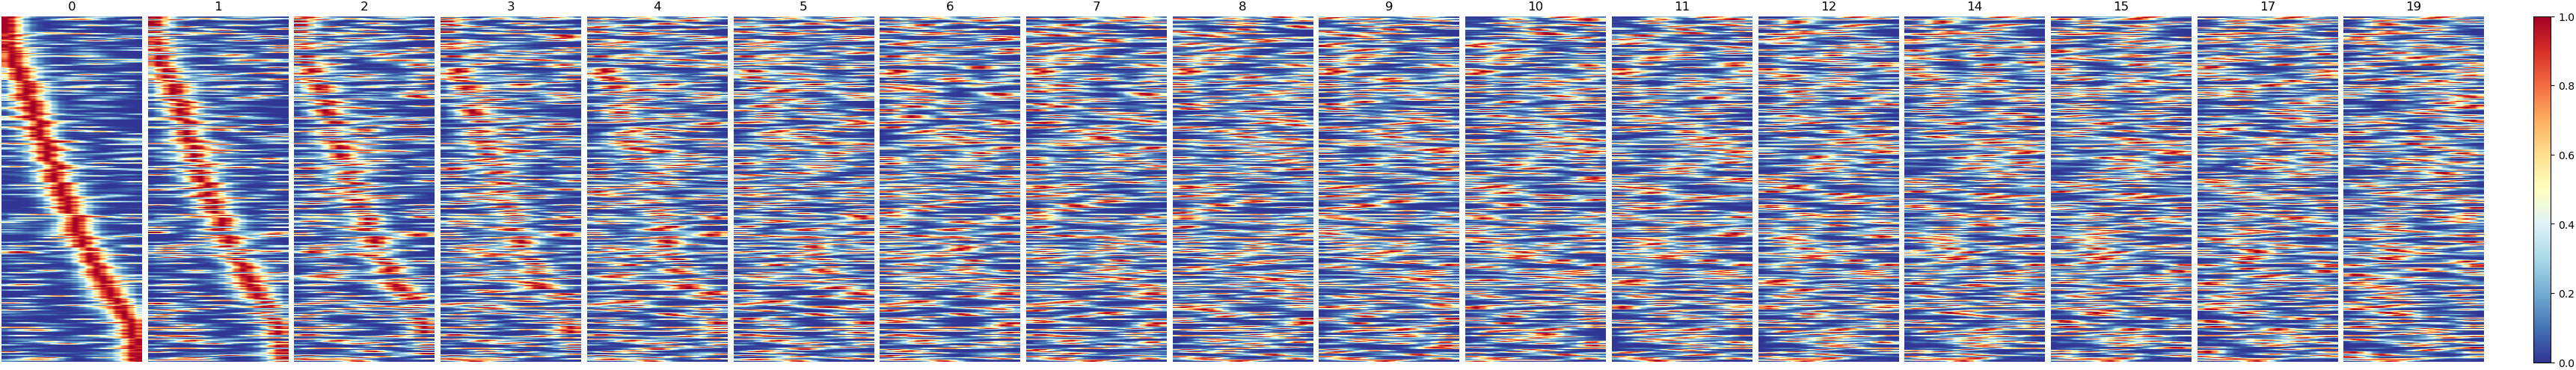

In [13]:
print_large('\n' + '='*50)
print_large('Drift simulation example')
print_large('='*50)

sim=analysis.simulate_drift(f'{DATA_ROOT}/170.h5', session='0', Context='Context1',
                             days=len(maps)+1,  drift_type='circular',dim_red=False,
                               standardize='stand', odd_even=True, global_seed=0, active_days=[reference]+maps, remove_day_inactive=True, max_remap_prob=0.3, amplitude_drift_prob=0.3, amplitude_change_scale=0.75)
print_large('Sorted within days')
plots.plot_arrays([maps[sim['sorts'][d]] for d,maps in enumerate(sim['maps'])], ['0']+maps, remove_zero_rows=True)
print_large('Sorted with day1')
plots.plot_arrays([maps[sim['sorts'][0]] for maps in sim['maps']], ['0']+maps, remove_zero_rows=True)
before_correlation = [pop.ManifoldAnalysis.population_correlation( maps, sim['maps'][0] ) for maps in sim['maps'] ]
